<a href="https://colab.research.google.com/github/RadhaKalluri/Nowak-Kalluri_TypeIISGN2026/blob/main/Copy_of_VClampRealvsModelFigurePaperFinal63026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install necessary plugins
!pip install pyparsing==2.4.7
!pip install numpy==2.0.2
!pip install brian2==2.9.0 --no-deps
!pip install pandas==2.2.2
!pip install brian2tools
!pip install matplotlib-venn
import pandas as pd
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from brian2 import *

  Using cached brian2tools-0.3-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools_scm-10.2.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pylems-0.6.9-py3-none-any.whl.metadata (5.0 kB)
  Using cached libneuroml-0.6.7-py3-none-any.whl.metadata (8.6 kB)
  Using cached markdown_strings-3.4.0-py2.py3-none-any.whl.metadata (7.5 kB)
  Using cached cython-3.2.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.8/390.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 146.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2

In [ ]:
#establish channel parameters
defaultclock.dt = 0.01*ms
start_scope()
Eh = -43*mV
EK = -81*mV
El = -65*mV
ENa = 81*mV

#Rothman and Manis Parameters
nf = 0.85  # proportion of n vs p kinetics
zss = 0.5 # steady state inactivation of glt
temp = 22.  # temperature in degree celcius
q10 = 3. ** ((temp - 22) / 10.)
# hcno current (octopus cell)
frac = 0.0
qt = 4.5 ** ((temp - 33.) / 10.)

# Classical Na channel  #This implementation incorporates the tweaks from Kalluri and Hight
eqs_na = """
ina = gnabar*m**3*h*(ENa-v) : amp/metre**2
dm/dt=q10*(minf-m)/mtau : 1
dh/dt=q10*(hinf-h)/htau : 1
minf = 1./(1+exp(-(vu + 38.) / 4.)) : 1
hinf = 1./(1+exp((vu + 65.) / 6.)) : 1
mtau =  ((10. / (5*exp((vu+60.) / 18.) + 36.*exp(-(vu+60.) / 25.))) + 0.04)*ms : second
htau =  ((100. / (7*exp((vu+60.) / 11.) + 10.*exp(-(vu+60.) / 25.))) + 0.6)*ms : second
gnabar: siemens/metre**2
"""
# KHT channel (delayed-rectifier K+); note that ptau is different than in the implementation shown in Brian for Rothman and Manis ptau = ((100. / (4*exp((vu+60) / 32.) + 5*exp(-(vu+60) / 22.))) + 5)*ms : second
eqs_kht = """
ikht = gkhtbar*(nf*n**2 + (1-nf)*p)*(EK-v) : amp/metre**2
dn/dt=q10*(ninf-n)/ntau : 1
dp/dt=q10*(pinf-p)/ptau : 1
ninf =   (1 + exp(-(vu + 15) / 5.))**-0.5 : 1
pinf =  1. / (1 + exp(-(vu + 23) / 6.)) : 1
ntau =  ((100. / (11*exp((vu+60) / 24.) + 21*exp(-(vu+60) / 23.))) + 0.7)*ms : second
ptau = ((100. / (4*exp((vu+60) / 32.) + 16*exp(-(vu+60) / 22.))) + 5)*ms : second
gkhtbar: siemens/metre**2
"""
# Ih channel (subthreshold adaptive, non-inactivating)
eqs_ih = """
ih = ghbar*r*(Eh-v) : amp/metre**2
dr/dt=q10*(rinf-r)/rtau : 1
rinf = 1. / (1+exp((vu + 100.) / 7.)) : 1
rtau = ((100000. / (237.*exp((vu+60.) / 12.) + 17.*exp(-(vu+60.) / 14.))) + 25.)*ms : second
ghbar: siemens/metre**2
"""

# KLT channel (low threshold K+)#winf = (1. / (1 + exp(-(vu + 48.) / 6.)))**0.25 : 1 ; winf = (1. / (1 + exp(-(vu + 44.) /8.4)))**0.25 : 1 # modified according to hight and kalluri 20xx
eqs_klt = """
iklt = gkltbar*w**4*z*(EK-v) : amp/metre**2
dw/dt=q10*(winf-w)/wtau : 1
dz/dt=q10*(zinf-z)/ztau : 1
winf = (1. / (1 + exp(-(vu + 48.) /8.)))**0.25 : 1
zinf = zss + ((1.-zss) / (1 + exp((vu + 71.) / 10.))) : 1
wtau = ((100. / (6.*exp((vu+60.) / 6.) + 16.*exp(-(vu+60.) / 45.))) + 1.5)*ms : second
ztau = ((1000. / (exp((vu+60.) / 20.) + exp(-(vu+60.) / 8.))) + 50)*ms : second
gkltbar: siemens/metre**2
"""

#Activation range of A-type current is modified here to be akin to Jagger and Houseley.  There isn't enough data to know if we should also tweak the kinetics of the current.
# Ka channel (transient K+)
eqs_ka = """
ika = gkabar*a**3*b*(EK-v): amp/metre**2
da/dt=q10*(ainf-a)/atau : 1
db/dt=q10*(binf-b)/btau : 1
ainf = (1. / (1 + exp(-(vu + 12) / 12.)))**0.33 : 1
binf = 1. / (1 + exp((vu + 76) / 20.)) : 1
atau = 1.5 *ms: second
btau = (6 + 20/(1 + exp((vu + 20)/10)))*ms : second
gkabar: siemens/metre**2
"""

# Leak
eqs_leak = """
ileak = gl*(El-v) : amp/metre**2
gl: siemens/metre**2
"""

#gClamp feedback amplifier gain
eqs_gClamp = """
iclamp = gclamp*(vc-v): amp/metre**2
gclamp : siemens/meter**2
vc : volt
"""

In [ ]:
#setup equation for estimating current/voltage
C = 1*uF/cm**2
eqs = """
dv/dt = (1/C)*(ileak + ina + ikht + ih + iklt + ika) + (iclamp*S)/(C*S): volt
vu = v/mV : 1  # unitless v
I : amp
S : metre**2
"""
eqs += eqs_leak + eqs_na + eqs_kht + eqs_ih + eqs_klt + eqs_ka +eqs_gClamp #add other channels when ready

In [ ]:
#establish capacitance
Cp1 = 6.5*pF
Cp2 = 5.5*pF #19.2 pF would be Type IIL
S1 = Cp1/C
S2 = Cp2/C
gmax = 60/1e-5
alpha = 0; #sustained-spiking model
beta = 1; #transient-spiking model
refractory_period = 8*ms
v_thresh = -30*mV

In [ ]:
# Create a neuron groups with the desired number of neurons and conductances based on example empirical data for type I and type II SGNs
N = 25
neurons1 = NeuronGroup(N, model=eqs, threshold='v > v_thresh', refractory = refractory_period, method='exponential_euler')
neurons2 = NeuronGroup(N, model=eqs, threshold='v > v_thresh',refractory = refractory_period, method='exponential_euler')

#Type I Model:
neurons1.S = S1
neurons1.gl = 0.3e-3*siemens/cm**2
neurons1.gnabar = 3.61e-3*siemens/cm**2
neurons1.gkhtbar = 2.09e-3*siemens/cm**2
neurons1.ghbar = 0.91e-3*siemens/cm**2
neurons1.gkltbar = 2.09e-3*siemens/cm**2
neurons1.gkabar = 0.11e-3*siemens/cm**2
neurons1.gclamp = 5000*siemens/cm**2 #feedback clamp is very large to minimize clamp error
mon_s1 = StateMonitor(neurons1, ['I','vc','v', 'iklt','ikht','ileak','ina','ika','ih'], record=True)


#Type II Model
neurons2.S = S2
neurons2.gl = 0.3e-3*siemens/cm**2
neurons2.gnabar = 1.61e-3*siemens/cm**2
neurons2.gkhtbar = 0.5e-3*siemens/cm**2
neurons2.ghbar = 0.91e-3*siemens/cm**2
neurons2.gkltbar = 0.25e-3*siemens/cm**2
neurons2.gkabar = 0.69e-3*siemens/cm**2
neurons2.gclamp = 5000*siemens/cm**2 #feedback clamp is very large to minimize clamp error
mon_s2 = StateMonitor(neurons2, ['I','vc','v', 'iklt','ikht','ileak','ina','ika','ih'], record=True)


In [ ]:
#create voltage clamp protocol
neurons1.vc = -65*mV
neurons2.vc = -65*mV
run(100*ms)
neurons1.vc = -120*mV
neurons2.vc = -120*mV
run(100*ms)
neurons1.vc = linspace(-90,30,N)*mV
neurons2.vc = linspace(-90,30,N)*mV
run(500*ms)

In [ ]:
#calculate total current and conductance
Iwhole1=mon_s1.ileak+mon_s1.ina+mon_s1.iklt+mon_s1.ikht+mon_s1.ika+mon_s1.ih
Iwhole2=mon_s2.ileak+mon_s2.ina+mon_s2.iklt+mon_s2.ikht+mon_s2.ika+mon_s2.ih

gwhole1 = Iwhole1[:,-1]/(mon_s1.vc[:,-1]-EK)/1e-3*siemens*cm**2
gwhole2 = Iwhole2[:,-1]/(mon_s2.vc[:,-1]-EK)/1e-3*siemens*cm**2

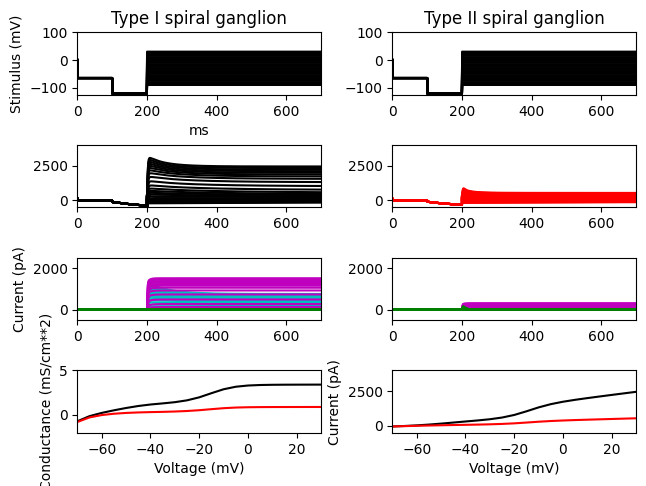

In [ ]:
#create plots
from re import M
subplot(421) #type I voltage stimulus
plot(mon_s1.t/ms,transpose(mon_s1.v)/mV,'k')
axis([0,700,-125,100])

title('Type I spiral ganglion')
xlabel('ms')
ylabel('Stimulus (mV)')
subplot(422) # type II voltage stimulus
plot(mon_s2.t/ms,transpose(mon_s2.v)/mV,'k')
axis([0,700,-125,100])
title('Type II spiral ganglion')

subplot(423) # type I model current response
plot(mon_s1.t/ms,transpose(-Iwhole1*S1/pA),'k')
axis([0,700,-500,4000])
subplot (424) # type II model current response
plot(mon_s2.t/ms,transpose(-Iwhole2*S2/pA),'r')
axis([0,700,-500,4000])

subplot(425) # type I model current response broken down by current type
#plot(mon_s1.t/ms,transpose(-mon_s1.ileak*S1/pA),'y')
plot(mon_s1.t/ms,transpose(-mon_s1.iklt*S1/pA),'c')
plot(mon_s1.t/ms,transpose(-mon_s1.ikht*S1/pA),'m')
plot(mon_s1.t/ms,transpose(-mon_s1.ika*S1/pA),'g')
ylabel('Current (pA)')
axis([0,700,-500,2500])
subplot(426) # type II model current response broken down by current type
plot(mon_s2.t/ms,transpose(-mon_s2.iklt*S2/pA),'c')
plot(mon_s2.t/ms,transpose(-mon_s2.ikht*S2/pA),'m')
plot(mon_s2.t/ms,transpose(-mon_s2.ika*S2/pA),'g')
axis([0,700,-500,2500])

subplot(427) #conductance by voltage input output functions
plot(mon_s1.vc[:,-1]/mV,-gwhole1,'k')
plot(mon_s2.vc[:,-1]/mV,-gwhole2,'r')
xlabel('Voltage (mV)')
ylabel('Conductance (mS/cm**2)')
axis([-70,30,-2,5])
subplot(428) #current by voltage input output functions
plot(mon_s1.vc[:,-1]/mV,-Iwhole1[:,-1]*S1/(pA),'k') # late current
plot(mon_s2.vc[:,-1]/mV,-Iwhole2[:,-1]*S2/(pA),'r') # late current
axis([-70,30,-500,4000])
ylabel('Current (pA)')
xlabel('Voltage (mV)')
#remove # to print pdf of plot
#plt.savefig("TypeIvsIIVoltageClampModel.pdf", format="pdf", bbox_inches="tight")
tight_layout(pad=0.5)

show()
#time.sleep(2)  # Ensure file system catches up
#from google.colab import files
#files.download("TypeIvsIIVoltageClampModel.pdf")

Extract the V/I curve from the current clamp recordings at steady state